# 02 - Exploratory Data Analysis

## Objective
Describe parking supply, demand, economics, competition, markets, and BD patterns that matter to acquisition prioritisation.

## Data source
PostgreSQL analytics analytical views plus daily and typical-hour fact tables.

## Methodology
Use focused descriptive summaries, rank/Pearson associations, contextual quadrants, and a restrained chart set. Associations are observational and are not interpreted as causal effects.

In [1]:
from pathlib import Path
import sys
from IPython.display import Image, display

cwd = Path.cwd().resolve()
REPO_ROOT = next(path for path in (cwd, *cwd.parents) if (path / 'database').exists() and (path / 'python').exists())
sys.path.insert(0, str(REPO_ROOT))

from python.analysis.data_access import load_analysis_inputs
from python.analysis.eda import (
    bd_conversion_breakdowns, classify_markets, competition_quadrants, demand_summary,
    parking_characteristics, peak_hour_windows, relationship_summary,
    revenue_efficiency_segments,
)

In [2]:
inputs = load_analysis_inputs([
    'acquisition_scores', 'parking_performance', 'daily_performance',
    'hourly_profile', 'locality_summary', 'outreach',
])
scores = inputs['acquisition_scores']
characteristics = parking_characteristics(scores)
demand = demand_summary(scores, inputs['daily_performance'], inputs['hourly_profile'])
peaks = peak_hour_windows(inputs['hourly_profile'])
relationships = relationship_summary(scores)
efficiency = revenue_efficiency_segments(inputs['parking_performance'])
quadrants, quadrant_cutoffs = competition_quadrants(scores)
markets, market_cutoffs = classify_markets(inputs['locality_summary'])
bd = bd_conversion_breakdowns(inputs['outreach'])

display(characteristics['by_type'])
display(peaks)
display(relationships)

,parking_type,parking_lots,median_capacity_cars,mean_capacity_cars,median_hourly_rate_inr,mean_hourly_rate_inr
6,Surface Lot,47,108.0,115.723404,50.0,52.553191
4,Office Complex,16,325.0,319.437500,45.0,46.875000
0,Basement,15,158.0,184.133333,55.0,63.000000
3,Multi-Level (MLCP),15,399.0,403.600000,50.0,49.000000
5,On-Street Authorised,15,58.0,62.000000,40.0,41.000000
1,Mall Parking,6,312.0,353.166667,50.0,52.500000
2,Metro Station Parking,6,202.0,211.666667,35.0,41.666667


,day_type,peak_cutoff_occupancy_pct,peak_hours,peak_windows,peak_hour_count,peak_mean_occupancy_pct
0,Weekday,40.24,"14:00, 15:00, 16:00, 17:00, 18:00, 19:00",14:00-19:00,6,43.39
1,Weekend,37.71,"14:00, 15:00, 16:00, 17:00, 18:00, 19:00",14:00-19:00,6,40.66


,relationship,x,y,n,spearman,pearson
0,Occupancy vs capacity,avg_occupancy_rate,capacity_cars,120,0.0867,0.0511
1,Occupancy vs hourly price,avg_occupancy_rate,hourly_rate_inr,120,0.2952,0.3353
2,Occupancy vs metro distance,avg_occupancy_rate,metro_distance_m,120,-0.6464,-0.6301
3,Occupancy vs commercial density proxy,avg_occupancy_rate,commercial_density_proxy,120,0.5823,0.5248
4,Occupancy vs destination density proxy,avg_occupancy_rate,destination_density_proxy,120,0.6054,0.5405
5,Bookings vs occupancy,avg_daily_platform_bookings,avg_occupancy_rate,120,0.6778,0.5928
6,Platform revenue vs capacity,expected_monthly_platform_revenue_inr,capacity_cars,120,0.7351,0.5457
7,Platform revenue vs occupancy,expected_monthly_platform_revenue_inr,avg_occupancy_rate,120,0.5372,0.5333


In [3]:
display(efficiency['efficiency_pattern'].value_counts().rename_axis('pattern').to_frame('lots'))
display(quadrants['competition_quadrant'].value_counts().rename_axis('quadrant').to_frame('lots'))
display(markets[[
    'locality_name', 'avg_acquisition_score', 'high_priority_count',
    'market_whitespace_score', 'market_class',
]].sort_values('market_whitespace_score', ascending=False))
display(bd[(bd['dimension'] == 'lead_source') & (bd['leads'] >= 5)])

,lots
pattern,
LARGE_INEFFICIENT,14
SMALL_HIGH_UTILIZATION,13


,lots
quadrant,
HIGH_DEMAND_HIGH_COMPETITION,39
LOW_DEMAND_LOW_COMPETITION,31
LOW_DEMAND_HIGH_COMPETITION,29
HIGH_DEMAND_LOW_COMPETITION,21


,locality_name,avg_acquisition_score,high_priority_count,market_whitespace_score,market_class
0,Connaught Place,63.89,8,67.94,STRONG
1,Nehru Place,66.12,9,66.35,STRONG
2,Karol Bagh,56.72,4,62.69,STRONG
3,Lajpat Nagar,57.64,2,49.73,STRONG
4,Rajouri Garden,43.30,0,31.50,STRONG
5,Golf Course Road,49.89,2,26.12,STRONG
6,Saket,40.09,0,23.64,EMERGING
7,Noida Sector 18,37.47,0,23.08,EMERGING
8,Botanical Garden Noida,35.34,0,20.83,EMERGING
9,Sector 29 Gurugram,37.44,0,20.13,WEAK


,dimension,segment,leads,acquired,acquisition_rate_pct,avg_days_to_acquisition,synthetic_caveat
5,lead_source,Partner Network,12,3,25.00,43.0,Descriptive synthetic funnel cut; not causal e...
4,lead_source,Inbound Enquiry,9,1,11.11,65.0,Descriptive synthetic funnel cut; not causal e...
6,lead_source,Referral,19,2,10.53,75.0,Descriptive synthetic funnel cut; not causal e...
1,lead_source,Cold Call,29,3,10.34,56.0,Descriptive synthetic funnel cut; not causal e...
0,lead_source,Broker,10,1,10.00,45.0,Descriptive synthetic funnel cut; not causal e...
2,lead_source,Desk Research,20,1,5.00,51.0,Descriptive synthetic funnel cut; not causal e...
3,lead_source,Field Survey,21,1,4.76,52.0,Descriptive synthetic funnel cut; not causal e...


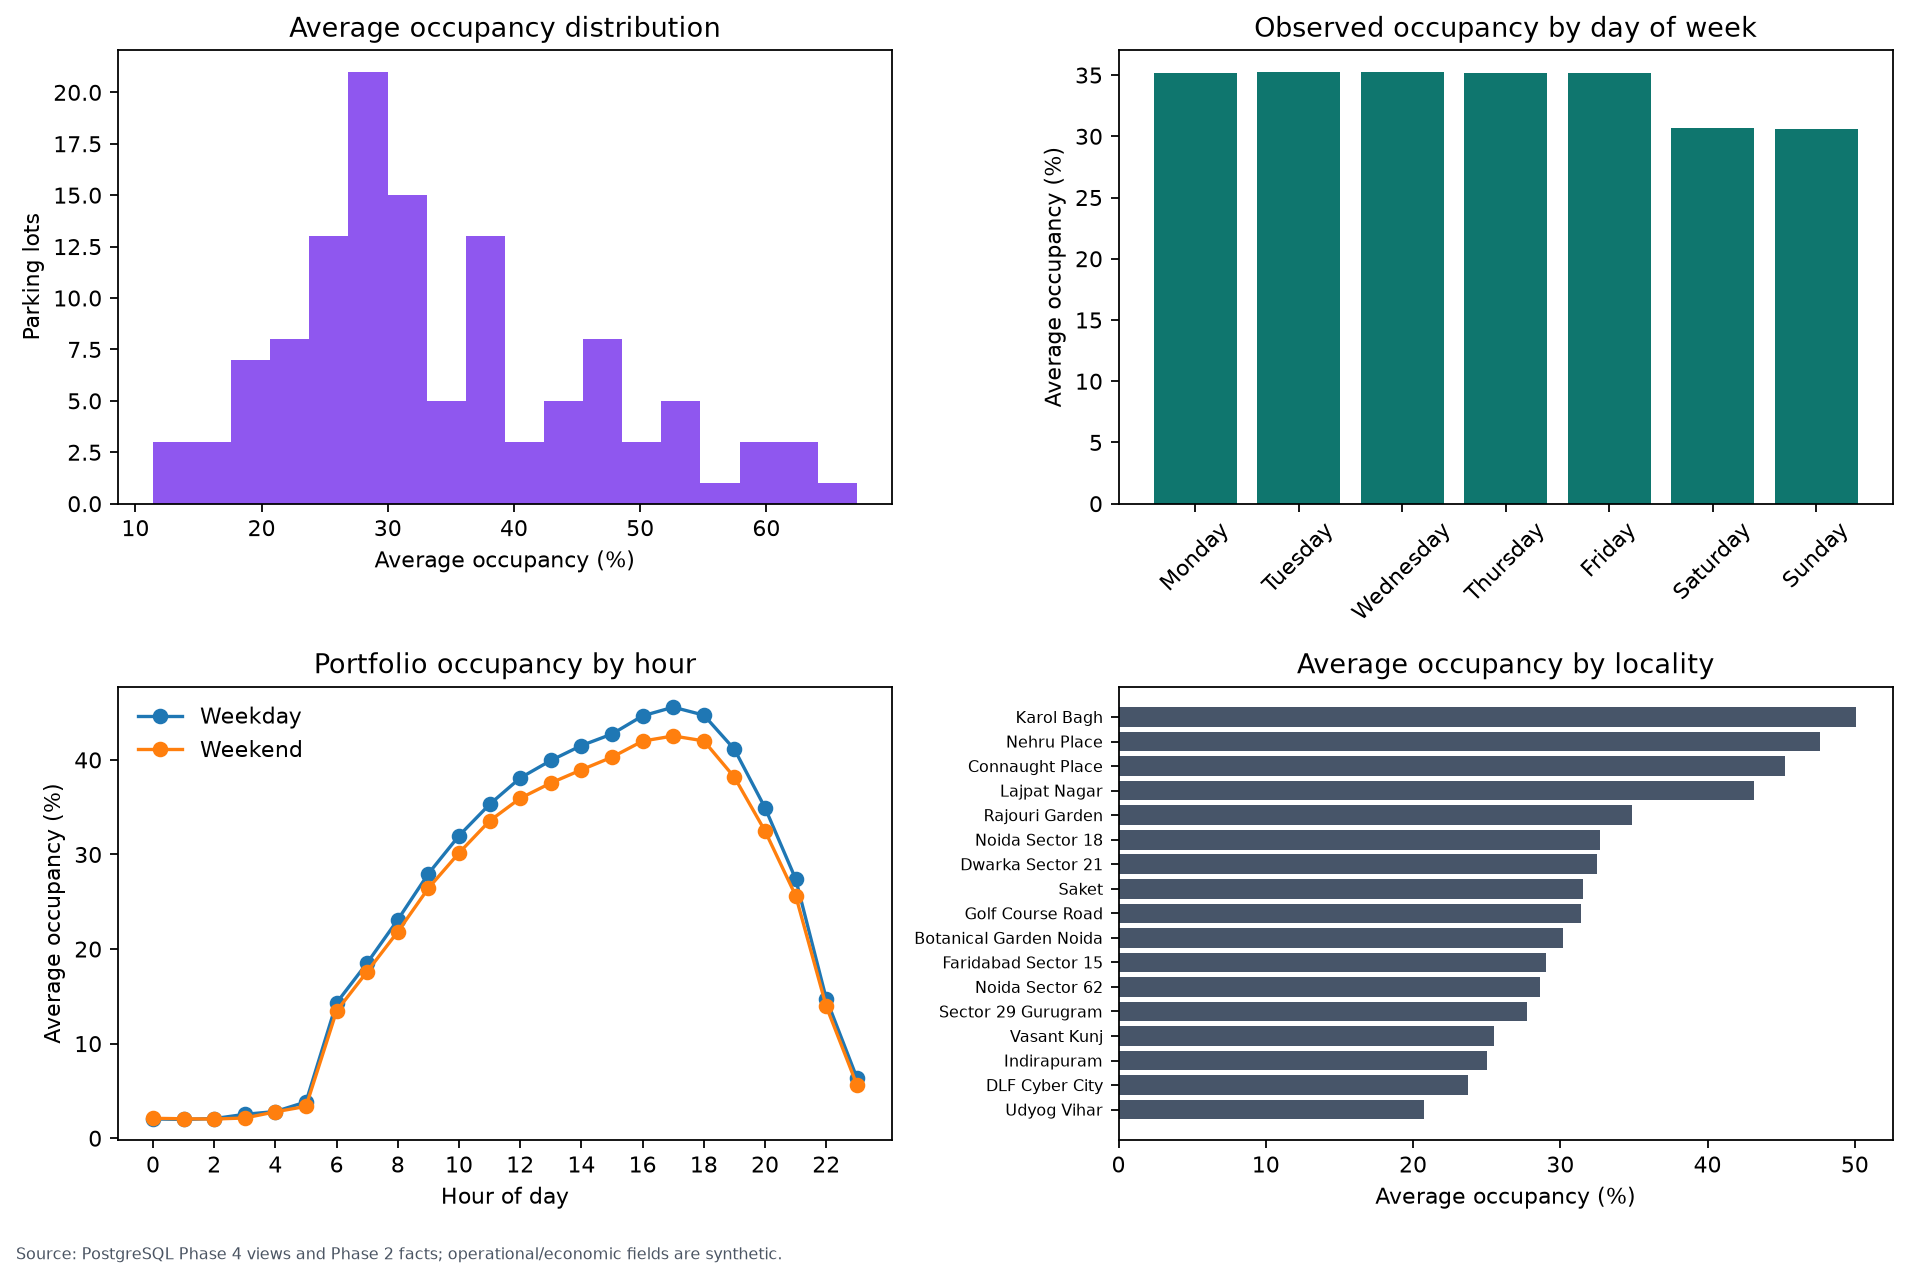

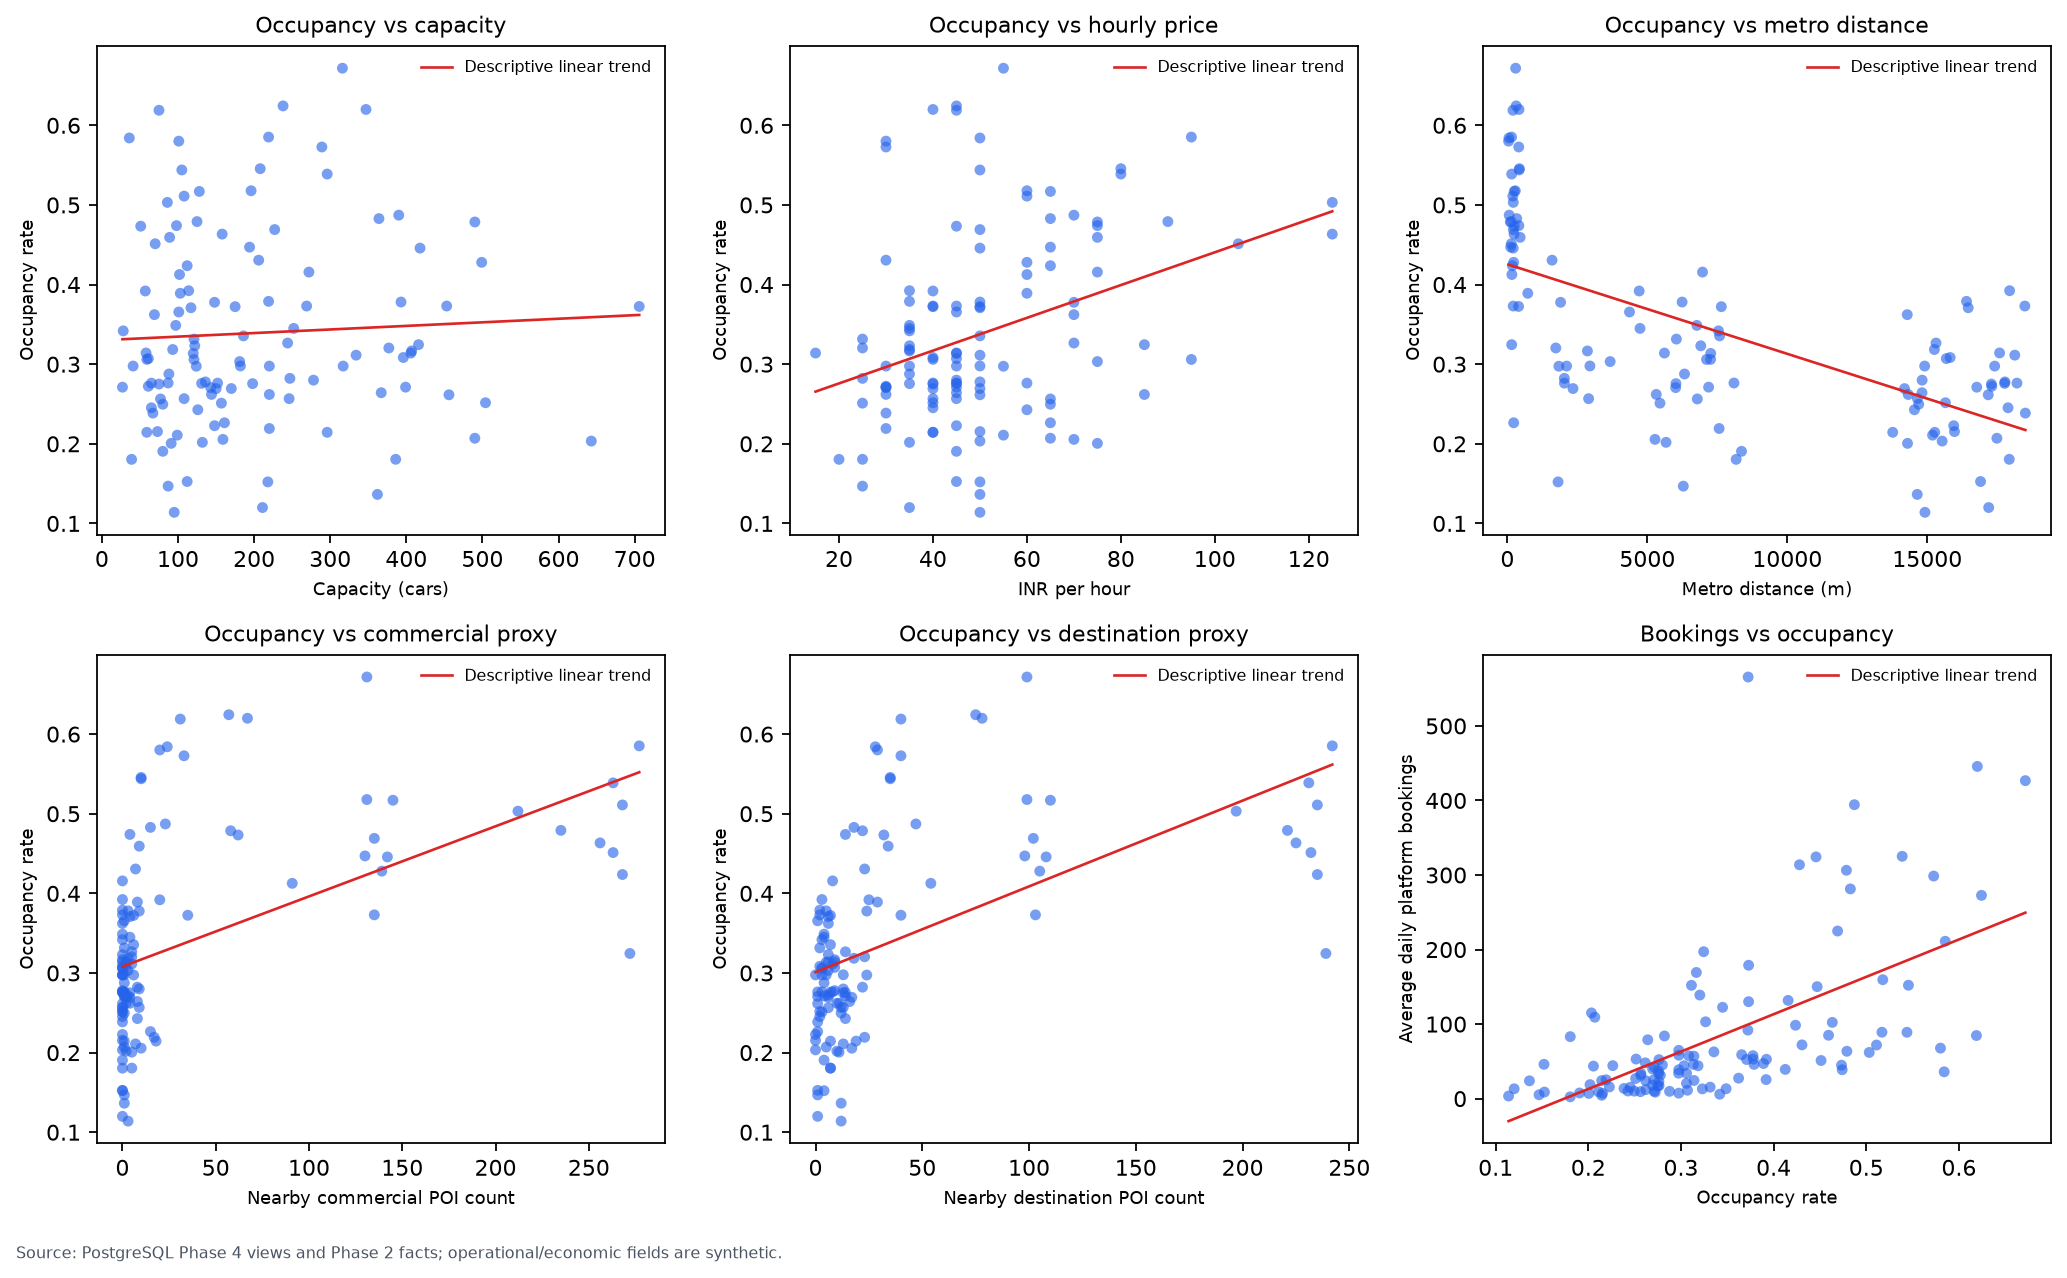

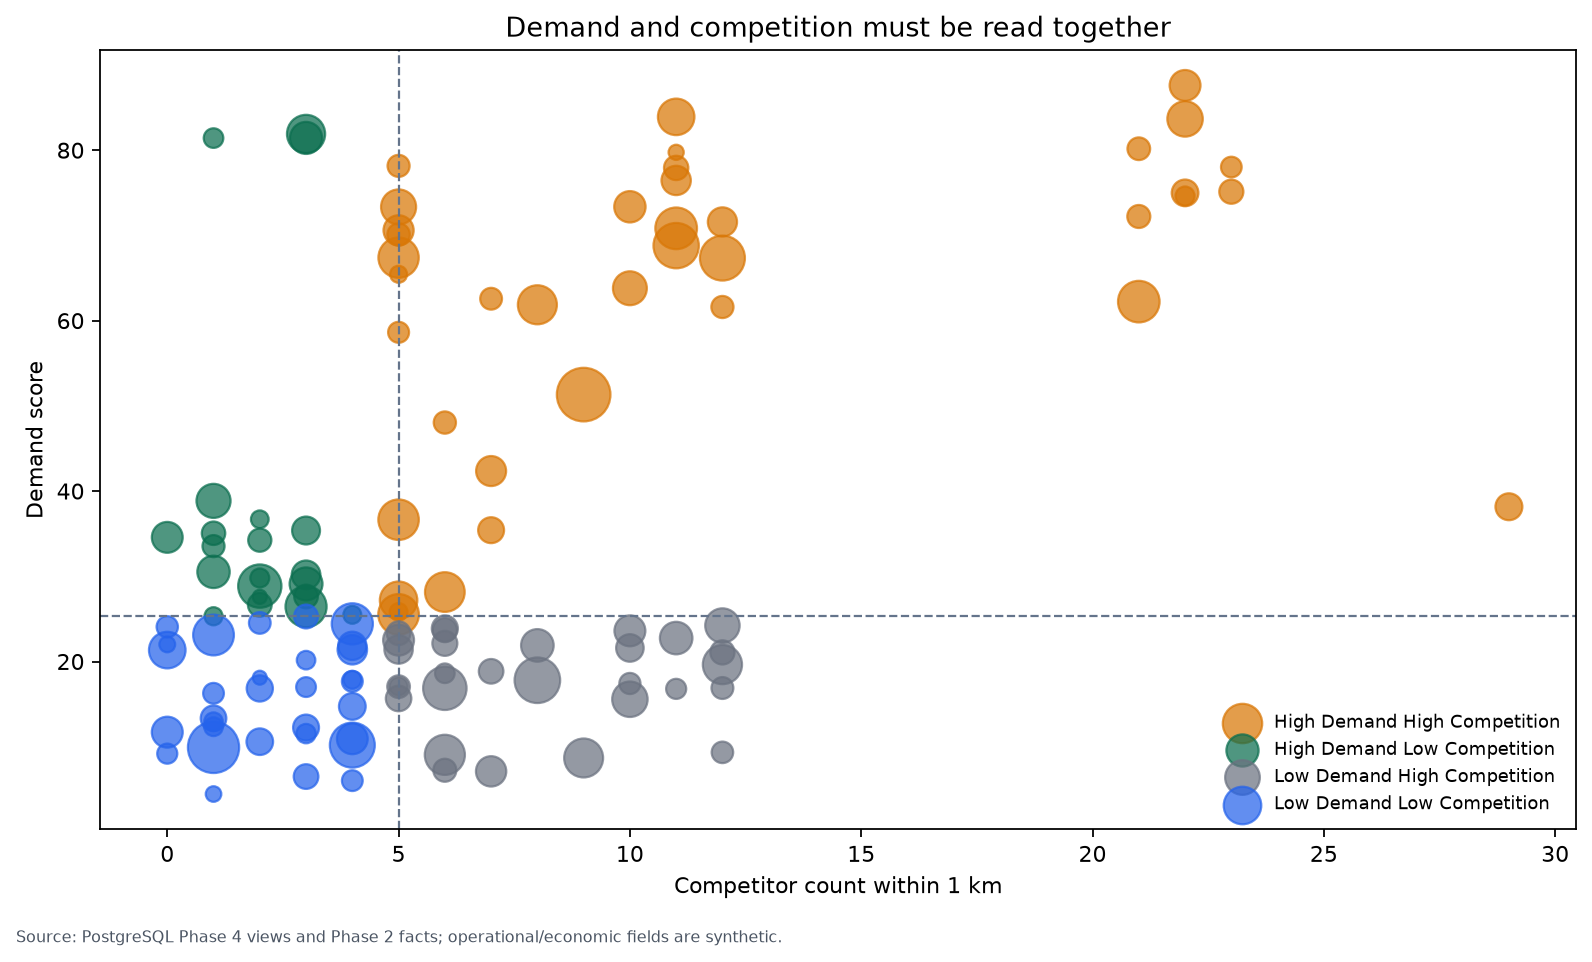

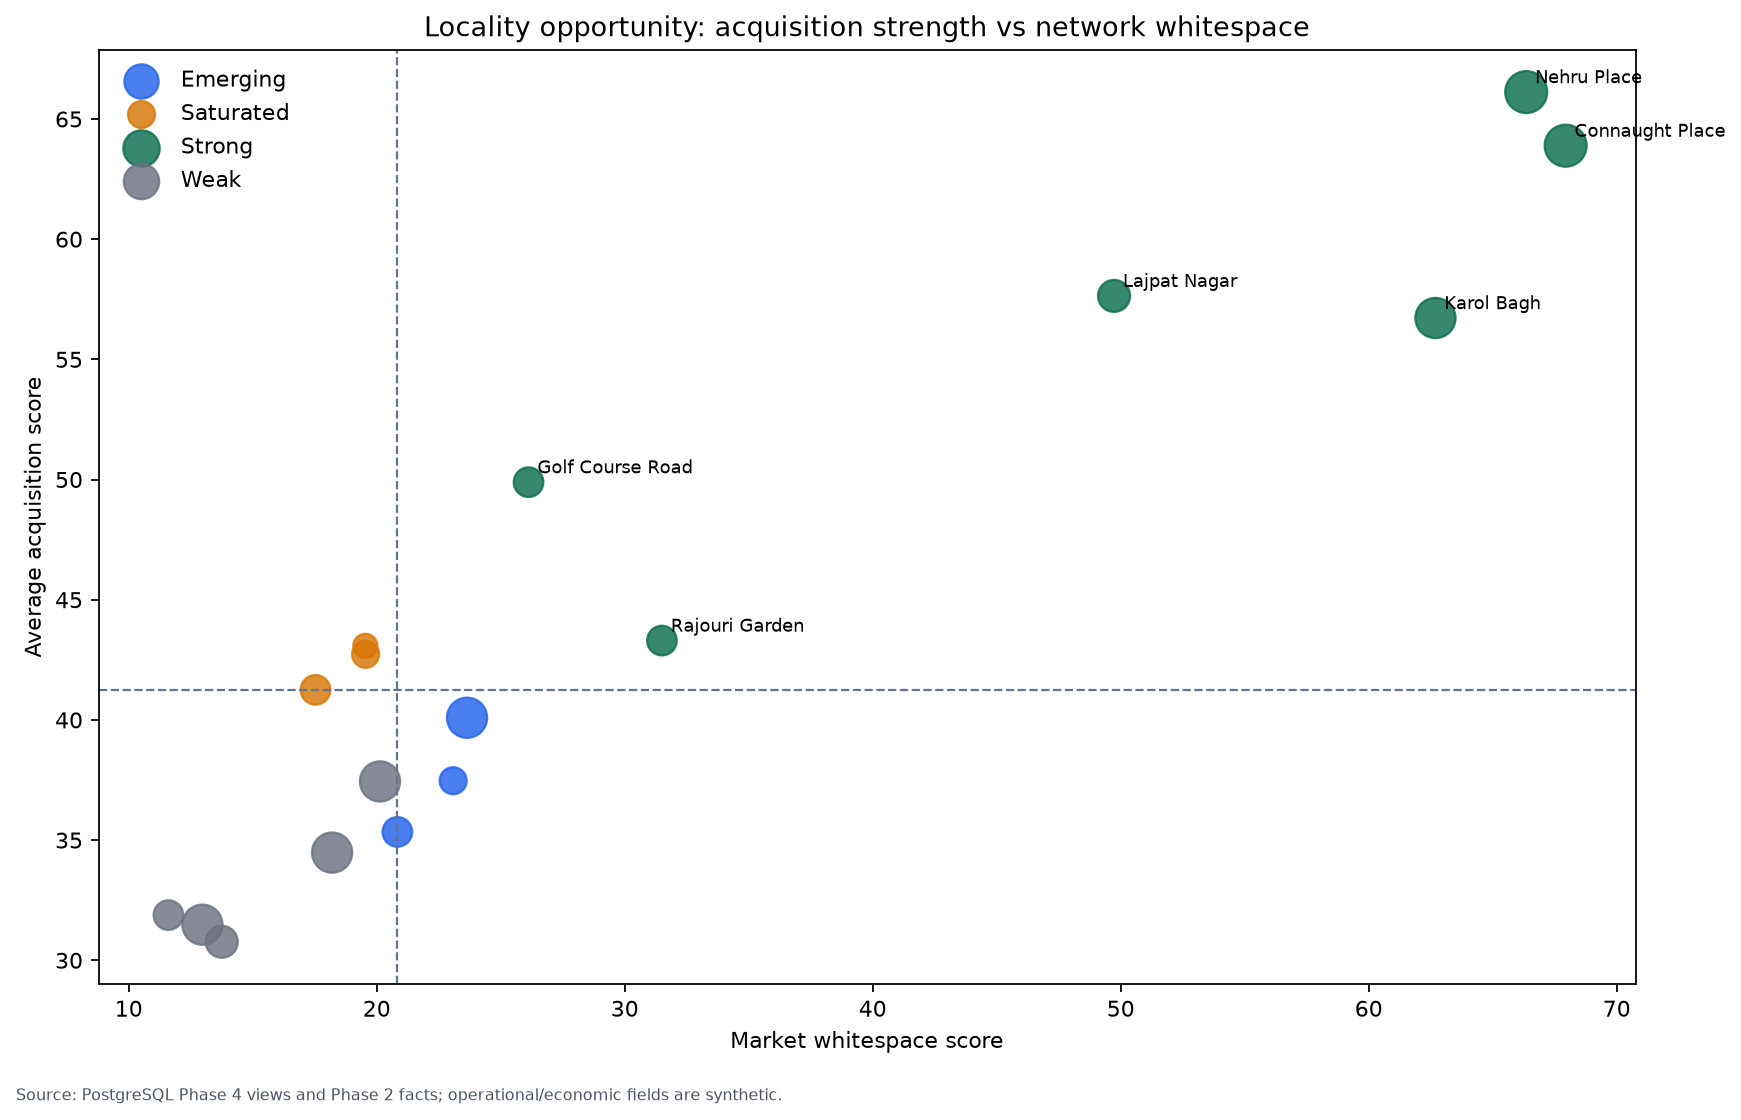

In [4]:
for filename in ['02_demand_patterns.png', '03_demand_relationships.png', '05_competition_quadrant.png', '06_market_opportunity.png']:
    display(Image(filename=REPO_ROOT / 'validation' / 'figures' / filename, width=900))

## Key findings

- The data-defined peak window is 14:00-19:00 for both weekdays and weekends; weekday peak-window occupancy averages 43.39% versus 40.66% on weekends.
- Occupancy is strongly negatively associated with metro distance (Spearman -0.65) and positively associated with the destination-density proxy (0.61). These are descriptive associations, not causal estimates.
- Bookings and occupancy move together (Spearman 0.68), while occupancy and capacity are nearly unrelated (0.09). Capacity alone therefore does not identify an attractive acquisition.
- The portfolio contains 14 large/low-efficiency lots and 13 small/high-utilisation lots under the documented median/quantile comparison rules.
- Connaught Place, Nehru Place, and Karol Bagh have the highest whitespace scores.
- The best synthetic lead-source acquisition rate among sources with at least five leads is Partner Network at 25% (3 of 12).

## Limitations

All relationships are descriptive within a synthetic/observational dataset. Competitor capacity is unavailable, market classes are relative to 17 localities, and the hypothetical PARK It Up coverage baseline is not real company inventory.